In [1]:
import awkward as ak
from coffea import processor
from coffea.nanoevents.methods import candidate
import uproot
from coffea.nanoevents import NanoEventsFactory, BaseSchema
import json
import hist
import numpy as np
import os, glob
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])
import pickle, glob
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)


mkdir -p failed for path /uscms_data/d1/bbbam/.cache/matplotlib: [Errno 30] Read-only file system: '/uscms_data'
Matplotlib created a temporary cache directory at /tmp/matplotlib-hjw4041v because there was an issue with the default path (/uscms_data/d1/bbbam/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [147]:
class MyProcessor(processor.ProcessorABC):
    def __init__(self):
        pass

    def process(self, events):
        # print(events.jetadR)
        # dataset_axis = hist.axis.StrCategory([], growth=True, name="dataset", label="Primary dataset")
        # dR_axis = hist.axis.Regular(10, 0, 0.5, name="dR", label="Jet A dR")
        dataset = events.metadata['dataset']
        # print("jetE--------------------",events.jetE)
        jet = ak.zip(
            {
                "TauMvis": ak.flatten(events.TauMvis),
                "TauMtautau": ak.flatten(events.TauMtautau),
                "TauMtautau_svFit": ak.flatten(events.TauMtautau_svFit),
                "Taumcoll": ak.flatten(events.Taumcoll),
               
                
               
            },
            with_name="PtEtaPhiMCandidate",
            behavior=candidate.behavior,
         
        )
        
        tauMvis = ak.to_numpy(jet.TauMvis)
        # print("min:", tauMvis.min(), "max:", tauMvis.max())
        tauMtautau = ak.to_numpy(jet.TauMtautau)
        tauMtautau_svFit = ak.to_numpy(jet.TauMtautau_svFit)
        taumcoll = ak.to_numpy(jet.Taumcoll)
       
        
        # Jet mass -----------------------------------------------------------

        TauMvis = (
            hist.Hist.new
            .StrCat(["TauMvis"], name="hmassjet")  # ← match this
            .Reg(30, 0, 150, name="massjet", label="Mass[GeV]")
            .Int64()
        )
        TauMvis.fill(hmassjet="TauMvis", massjet=tauMvis)  # ← to this
    
        # A mass  -----------------------------------------------------------
        
        TauMtautau = (
            hist.Hist.new
            .StrCat(["TauMtautau"], name="hmassjet")  # 
            .Reg(70, 0, 350, name="massjet", label="Mass[GeV]")
            .Int64()
        )
        TauMtautau.fill(hmassjet="TauMtautau", massjet=tauMtautau)  # 

        
        # JET PT -----------------------------------------------------------
        
        TauMtautau_svFit = (
            hist.Hist.new
            .StrCat(["TauMtautau_svFit"], name="hmassjet")  #
            .Reg(30, 25, 175, name="massjet", label="Mass[GeV]")
            .Int64()
        )
        TauMtautau_svFit.fill(hmassjet="TauMtautau_svFit", massjet=tauMtautau_svFit)  # 

      
        # A pt  -----------------------------------------------------------
        
        Taumcoll = (
            hist.Hist.new
            .StrCat(["Taumcoll"], name="hmassjet")  #
            .Reg(70, 0, 350, name="massjet", label="Mass[GeV]")
            .Int64()
        )
        Taumcoll.fill(hmassjet="Taumcoll", massjet=taumcoll)  #

        
        
        
        return {
            dataset: {
                "entries": len(events),
                "TauMvis":TauMvis,
                "TauMtautau":TauMtautau,
                "TauMtautau_svFit":TauMtautau_svFit,
                "Taumcoll":Taumcoll,
                # "tau1_pt":Tau1_pt,
                # "tau2_pt":Tau2_pt,
                # "a_eta":A_eta,
                # "a_phi":A_phi,
                # "tau1_jet_dr":tau1_jet_dR,
                # "tau2_jet_dr":tau2_jet_dR,
                # "taus_dr":taus_dR,
                # "a_jet_dr":a_jet_dR,
                # "recotau1_jet_dr":recotau1_jet_dR,
                # "recotau2_jet_dr":recotau2_jet_dR,
                # "number_gen_tau":gen_Tau,
                # "number_reco_tau":reco_Tau,
                # "amass":amass,
               
            }
        }

    def postprocess(self, accumulator):
        pass

In [148]:
with open("Higgs_mass_M3p7_GeV.json", "r") as fin:
    Higgs_mass_M3p7_GeV = json.load(fin)
with open("Higgs_mass_M4_GeV.json", "r") as fin:
    Higgs_mass_M4_GeV = json.load(fin)
with open("Higgs_mass_M5_GeV.json", "r") as fin:
    Higgs_mass_M5_GeV = json.load(fin)
with open("Higgs_mass_M6_GeV.json", "r") as fin:
    Higgs_mass_M6_GeV = json.load(fin)
with open("Higgs_mass_M8_GeV.json", "r") as fin:
    Higgs_mass_M8_GeV = json.load(fin)

with open("Higgs_mass_DYTo2L_GeV.json", "r") as fin:
    Higgs_mass_DYTo2L_GeV = json.load(fin)
with open("Higgs_mass_HTo2Tau_GeV.json", "r") as fin:
    Higgs_mass_HTo2Tau_GeV = json.load(fin)
with open("Higgs_mass_QCD_GeV.json", "r") as fin:
    Higgs_mass_QCD_GeV = json.load(fin)
with open("Higgs_mass_TTbar_GeV.json", "r") as fin:
    Higgs_mass_TTbar_GeV = json.load(fin)
with open("Higgs_mass_Wjets_GeV.json", "r") as fin:
    Higgs_mass_Wjets_GeV = json.load(fin)


fileset = {
    'Higgs_mass_M3p7_GeV': Higgs_mass_M3p7_GeV
    ,'Higgs_mass_M4_GeV': Higgs_mass_M4_GeV
    ,'Higgs_mass_M5_GeV': Higgs_mass_M5_GeV
    ,'Higgs_mass_M6_GeV': Higgs_mass_M6_GeV
    ,'Higgs_mass_M8_GeV': Higgs_mass_M8_GeV

    ,'Higgs_mass_DYTo2L_GeV': Higgs_mass_DYTo2L_GeV
    ,'Higgs_mass_HTo2Tau_GeV': Higgs_mass_HTo2Tau_GeV
    ,'Higgs_mass_QCD_GeV': Higgs_mass_QCD_GeV
    ,'Higgs_mass_TTbar_GeV': Higgs_mass_TTbar_GeV
    ,'Higgs_mass_Wjets_GeV': Higgs_mass_Wjets_GeV
    


}



In [149]:
futures_run = processor.Runner(
    executor = processor.FuturesExecutor(compression=None, workers=10),
    schema=BaseSchema,
    # maxchunks=10,
)

out = futures_run(
    fileset,
    treename='/fevt/RHTree',
    # "RHTree",
    processor_instance=MyProcessor()
)
with open('Higgs_mass.pkl', 'wb') as f:
    pickle.dump(out, f)

print("Higgs_mass.pkl")

Output()

Higgs_mass.pkl


In [56]:
# fig, ax = plt.subplots()
# out["train_mass"]["tau1_pt"].plot1d(ax=ax,histtype='step',color="r")
# out["train_mass"]["tau2_pt"].plot1d(ax=ax,histtype='step',color="b")
# # ax.set_yscale("log")
# ax.legend(title="pT Dist")
# hep.cms.label(llabel="Simulation Preliminary", rlabel="13 TeV", loc=0, ax=ax)

In [117]:
# out

In [150]:
out_dir='../analysis_run3/AN_Note_Plot/Higgs_Mass'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)

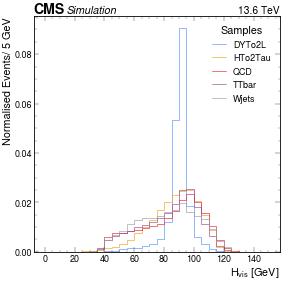

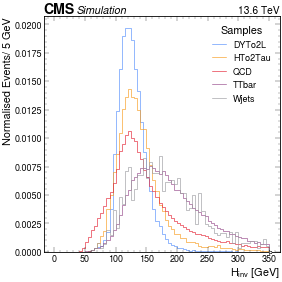

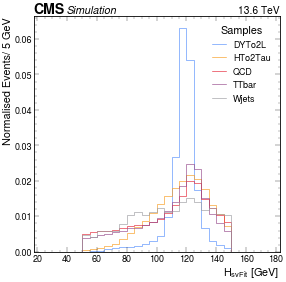

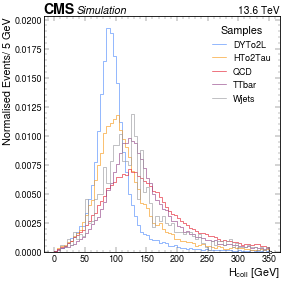

In [155]:
import pickle
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use(hep.style.CMS)

with open('Higgs_mass.pkl', 'rb') as f:
    out = pickle.load(f)

samples = [
    # 'Higgs_mass_M3p7_GeV',
    # 'Higgs_mass_M4_GeV',
    # 'Higgs_mass_M5_GeV',
    # 'Higgs_mass_M6_GeV',
    # 'Higgs_mass_M8_GeV',
    'Higgs_mass_DYTo2L_GeV',
    'Higgs_mass_HTo2Tau_GeV',
    'Higgs_mass_QCD_GeV',
    'Higgs_mass_TTbar_GeV',
    'Higgs_mass_Wjets_GeV'
]

dpi_ = 30

fig, ax = plt.subplots(dpi=dpi_)
for sample in samples:
    out[sample]["TauMvis"].plot1d(
        ax=ax,
        density=True,
        label=sample.replace("Higgs_mass_", "").replace("_GeV", "")
    )

ax.set_xlabel(r"$H_{vis}$ [GeV]")
ax.set_ylabel("Normalised Events/ 5 GeV")
ax.legend(title="Samples")

# Optional
# ax.set_yscale("log")

hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

plt.tight_layout()
# plt.savefig(f'{out_dir}/Higgs_mass_visible_bakground.pdf',facecolor='w',dpi=300)
#


fig, ax = plt.subplots(dpi=dpi_)
for sample in samples:
    out[sample]["TauMtautau"].plot1d(
        ax=ax,
        density=True,
        label=sample.replace("Higgs_mass_", "").replace("_GeV", "")
    )

ax.set_xlabel(r"$H_{inv}$ [GeV]")
ax.set_ylabel("Normalised Events/ 5 GeV")
ax.legend(title="Samples")

# Optional
# ax.set_yscale("log")

hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

plt.tight_layout()
# plt.savefig(f'{out_dir}/Higgs_mass_inv_bakground.pdf',facecolor='w',dpi=300)


fig, ax = plt.subplots(dpi=dpi_)
for sample in samples:
    out[sample]["TauMtautau_svFit"].plot1d(
        ax=ax,
        density=True,
        label=sample.replace("Higgs_mass_", "").replace("_GeV", "")
    )

ax.set_xlabel(r"$H_{svFit}$ [GeV]")
ax.set_ylabel("Normalised Events/ 5 GeV")
ax.legend(title="Samples")

# Optional
# ax.set_yscale("log")

hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

plt.tight_layout()
# plt.savefig(f'{out_dir}/Higgs_mass_svFit_approxmation_bakground.pdf',facecolor='w',dpi=300)

fig, ax = plt.subplots(dpi=dpi_)
for sample in samples:
    out[sample]["Taumcoll"].plot1d(
        ax=ax,
        density=True,
        label=sample.replace("Higgs_mass_", "").replace("_GeV", "")
    )

ax.set_xlabel(r"$H_{coll}$ [GeV]")
ax.set_ylabel("Normalised Events/ 5 GeV")
ax.legend(title="Samples")

# Optional
# ax.set_yscale("log")

hep.cms.label(
    llabel="Simulation",
    rlabel="13.6 TeV",
    loc=0,
    ax=ax
)

plt.tight_layout()
# plt.savefig(f'{out_dir}/Higgs_mass_coliner_approxmation_bakground.pdf',facecolor='w',dpi=300)



